In [1]:
import numpy as np
import math
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import breakvar_heteroskedasticity_test
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from pmdarima import auto_arima
from scipy.optimize import minimize
from epftoolbox.evaluation import GW
from tqdm import tqdm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [9]:
data_base = pd.read_csv("C:/Users/aless/Desktop/Codes/masters/SDM/dados_energia.csv")

In [15]:
data.head()

subsistema,Nordeste,Norte,Sudeste / Centro-Oeste,Sul
mes,,,,
2000-01-01,14599.677419,10428.354839,39381.967742,6734.322581
2000-02-01,22737.551724,11706.551724,59666.000000,6153.586207
2000-03-01,29811.322581,12339.774194,81075.774194,7518.258065
2000-04-01,35065.900000,12629.566667,92423.800000,6463.166667
2000-05-01,34718.483871,12521.419355,87995.387097,4934.322581


In [11]:
data_base['mes'] = pd.to_datetime(data_base.mes)
data = data_base.pivot_table(index='mes', columns='subsistema', values='energia_armazenada')

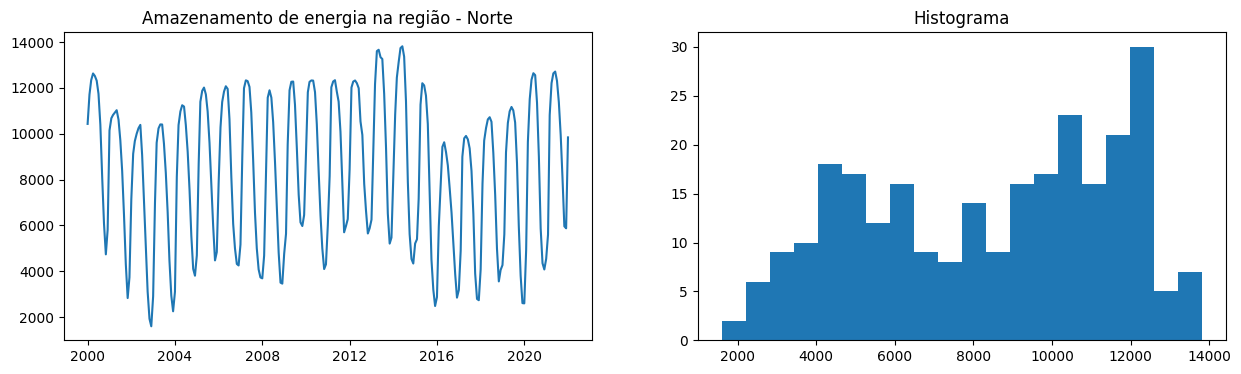

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(15,4))

reg = 'Norte'
ax[0].plot(data[reg])
ax[0].set_title(f'Amazenamento de energia na região - {reg}')

ax[1].hist(data[reg], bins=20)
ax[1].set_title('Histograma')

plt.show()

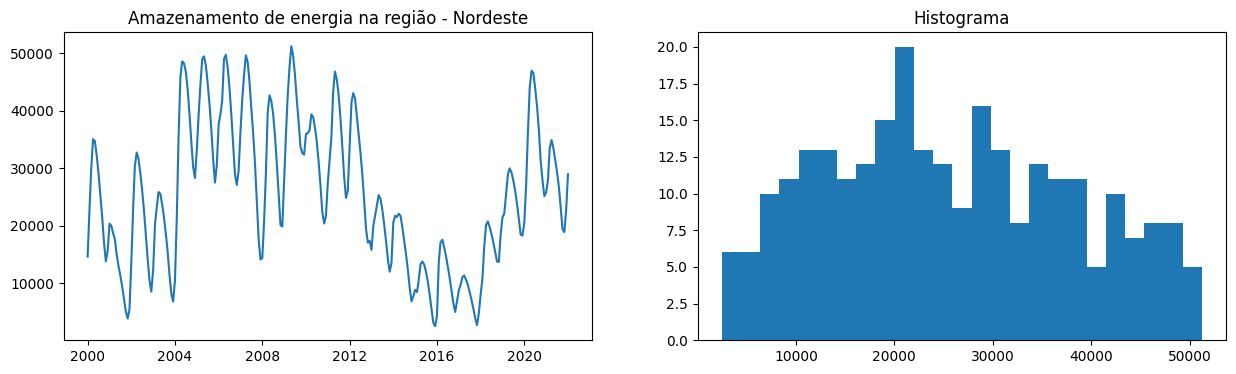

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15,4))

reg = 'Nordeste'
ax[0].plot(data[reg])
ax[0].set_title(f'Amazenamento de energia na região - {reg}')

ax[1].hist(data[reg], bins=25)
ax[1].set_title('Histograma')

plt.show()

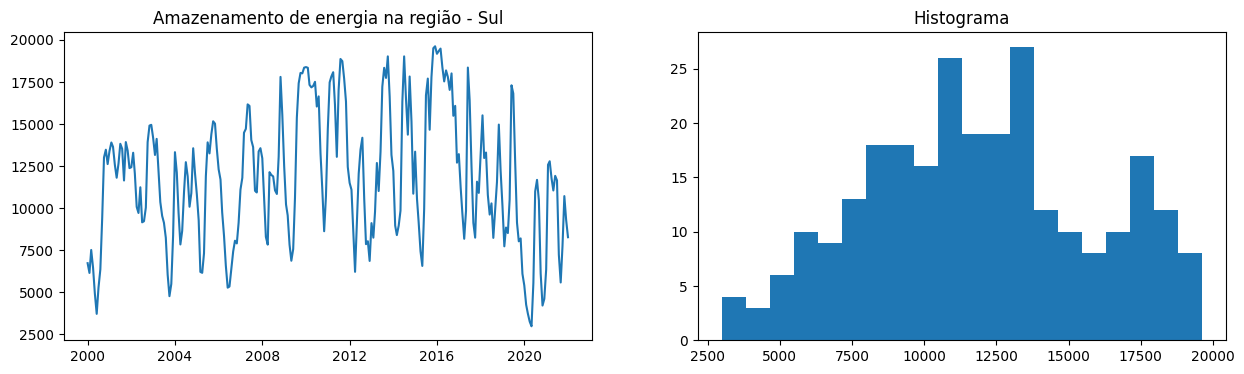

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(15,4))

reg = 'Sul'
ax[0].plot(data[reg])
ax[0].set_title(f'Amazenamento de energia na região - {reg}')

ax[1].hist(data[reg], bins=20)
ax[1].set_title('Histograma')

plt.show()

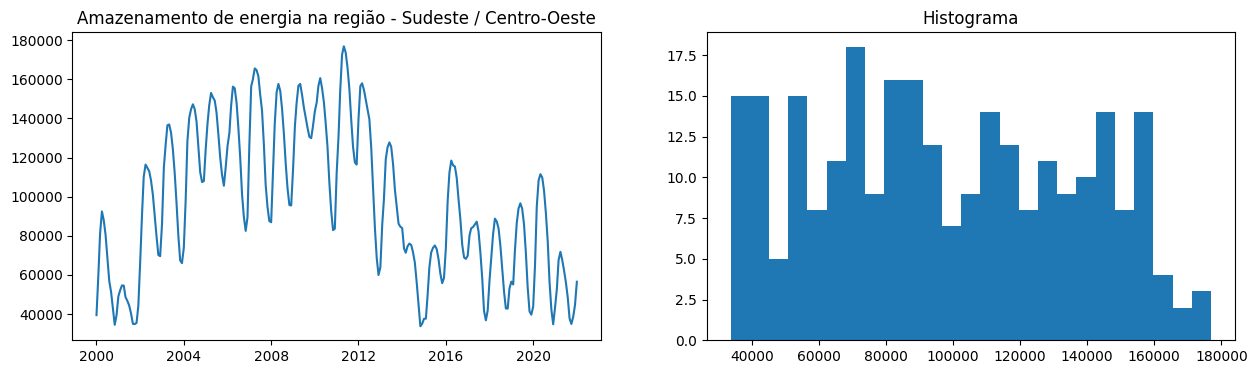

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(15,4))

reg = 'Sudeste / Centro-Oeste'
ax[0].plot(data[reg])
ax[0].set_title(f'Amazenamento de energia na região - {reg}')

ax[1].hist(data[reg], bins=25)
ax[1].set_title('Histograma')

plt.show()

In [44]:
series = data[['Sudeste / Centro-Oeste']].rename(columns={'Sudeste / Centro-Oeste': 'armazenamento'})

# metadados
pd.set_option('display.max_colwidth', None)
pd.DataFrame(index=['Metadados'], data={
    'Fonte':'''Base de dados de energia armazenada (EAR) do Operador Nacional do Sistema Elétrico (ONS)''', 
    'Unidade':'Megawatt (MW)',
    'Período da série': '{} a {}'.format(series.index[0].strftime('%d/%m/%Y'), series.index[-1].strftime('%d/%m/%Y'))
}).T

,Metadados
Fonte,Base de dados de energia armazenada (EAR) do Operador Nacional do Sistema Elétrico (ONS)
Unidade,Megawatt (MW)
Período da série,01/01/2000 a 01/01/2022


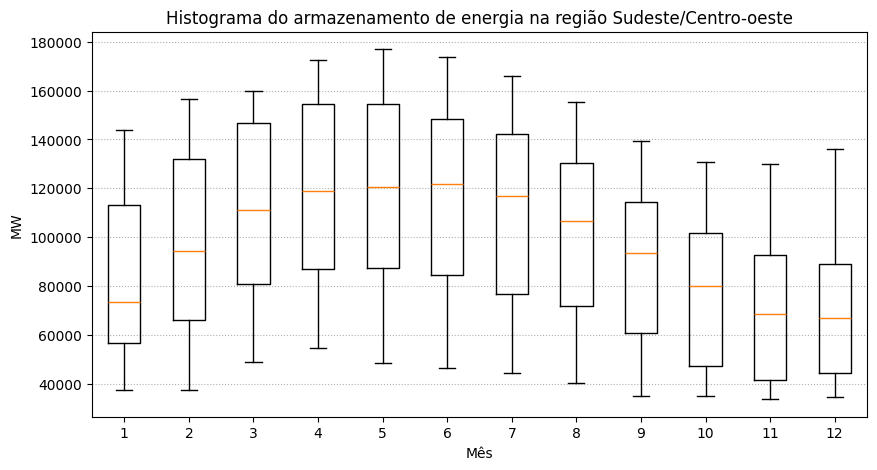

In [43]:
fig, ax = plt.subplots(figsize=(10,5))
plot_data = (series
    .pivot_table(columns=series.index.month, index=series.index.year, values='armazenamento')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_ylabel('MW')
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma do armazenamento de energia na região Sudeste/Centro-oeste')
plt.show()

In [35]:
series.to_csv("C:/Users/aless/Desktop/Codes/masters/SDM/dados_energia_sudeste.csv")